# Fly connectome bimodularity
Reproduces the bimodularity-style experiments from the `Bimodularity-Figures` notebook on the fly connectome (`connections_princeton.csv`). The notebook builds a directed weighted graph, computes a directed modularity matrix, performs SVD, clusters edges into bicommunities, and visualizes the resulting sending/receiving communities with rich plots.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec

sns.set_context('talk')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlepad'] = 12


In [2]:
DATA_DIR = Path('../data/raw')
CONNECTIONS_PATH = DATA_DIR / 'connections_princeton.csv'

N_CLUSTERS = 6
N_VECTORS = 6
TOP_N_NODES = 10000  # adjust to control size; increase for richer structure if resources allow
EDGE_WEIGHT_COL = 'syn_count'

assert CONNECTIONS_PATH.exists(), 'connections_princeton.csv missing'
CONNECTIONS_PATH


PosixPath('../data/raw/connections_princeton.csv')

In [3]:
connections = pd.read_csv(CONNECTIONS_PATH)
connections = connections[['pre_root_id', 'post_root_id', EDGE_WEIGHT_COL, 'neuropil', 'nt_type']]
connections.head()


,pre_root_id,post_root_id,syn_count,neuropil,nt_type
0,720575940625363947,720575940623224444,12,ME_L,GABA
1,720575940630432382,720575940618518557,67,ME_L,ACH
2,720575940627314521,720575940626337738,10,ME_L,GABA
3,720575940620280405,720575940620204726,15,ME_L,ACH
4,720575940636942447,720575940613789411,1,LA_L,GLUT


## Preprocess graph (reindex, optionally filter)
- Compute per-node strength (incoming + outgoing synapses).
- Keep the top `TOP_N_NODES` strongest nodes to keep matrices workable.
- Reindex nodes to consecutive integers for dense matrices.


In [4]:
out_strength = connections.groupby('pre_root_id')[EDGE_WEIGHT_COL].sum()
in_strength = connections.groupby('post_root_id')[EDGE_WEIGHT_COL].sum()
strength = out_strength.add(in_strength, fill_value=0)

if TOP_N_NODES is not None:
    keep_nodes = strength.sort_values(ascending=False).head(TOP_N_NODES).index
    filtered = connections[connections['pre_root_id'].isin(keep_nodes) & connections['post_root_id'].isin(keep_nodes)].copy()
else:
    keep_nodes = strength.index
    filtered = connections.copy()

node_list = pd.Index(sorted(keep_nodes))
node_to_idx = {n: i for i, n in enumerate(node_list)}

filtered['pre_idx'] = filtered['pre_root_id'].map(node_to_idx)
filtered['post_idx'] = filtered['post_root_id'].map(node_to_idx)

n = len(node_list)
adj = np.zeros((n, n), dtype=float)
for _, row in filtered.iterrows():
    adj[int(row['pre_idx']), int(row['post_idx'])] += row[EDGE_WEIGHT_COL]

print(f'Nodes kept: {n}, edges kept: {len(filtered):,}, total synapses: {filtered[EDGE_WEIGHT_COL].sum():,}')
adj


Nodes kept: 10000, edges kept: 1,015,225, total synapses: 12,347,988


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10000))

## Helper functions (directed modularity, SVD, bicommunities)
These replicate the logic of the original bimodularity utilities inside the notebook.


In [5]:
from typing import Tuple

def modularity_matrix(A: np.ndarray, null_model: str = 'outin') -> np.ndarray:
    """Directed modularity matrix with out*in null model."""
    kout = A.sum(axis=1, keepdims=True)
    kin = A.sum(axis=0, keepdims=True)
    m = A.sum()
    if m == 0:
        return np.zeros_like(A)
    if null_model == 'outin':
        P = kout @ kin / m
    else:
        raise ValueError("Only 'outin' null model supported here")
    return A - P

def sorted_svd(B: np.ndarray):
    U, S, Vt = np.linalg.svd(B, full_matrices=False)
    order = np.argsort(S)[::-1]
    return U[:, order], S[order], Vt[order].T

def edge_bicommunities(B: np.ndarray, U: np.ndarray, V: np.ndarray, n_vectors: int = 4,
                       n_clusters: int = 5, random_state: int = 0):
    """Cluster edges using top singular vectors (sending=U, receiving=V)."""
    u_emb = U[:, :n_vectors] * np.sqrt(np.maximum(0, np.abs(B)).mean())
    v_emb = V[:, :n_vectors] * np.sqrt(np.maximum(0, np.abs(B)).mean())
    send_idx, recv_idx = np.nonzero(B)
    feats = np.hstack([u_emb[send_idx], v_emb[recv_idx]])
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=random_state)
    labels = km.fit_predict(feats)
    return send_idx, recv_idx, labels, km

def get_node_communities(edge_u, edge_v, edge_labels, n_nodes: int, method: str = 'majority'):
    """Infer sending/receiving communities per node from edge labels."""
    send_comm = np.zeros(n_nodes, dtype=int)
    recv_comm = np.zeros(n_nodes, dtype=int)
    for node in range(n_nodes):
        outgoing = edge_labels[edge_u == node]
        incoming = edge_labels[edge_v == node]
        if len(outgoing):
            send_comm[node] = np.bincount(outgoing).argmax()
        if len(incoming):
            recv_comm[node] = np.bincount(incoming).argmax()
    return send_comm, recv_comm

def bimodularity_index(A: np.ndarray, send_comm: np.ndarray, recv_comm: np.ndarray) -> np.ndarray:
    """Simple bimodularity score: fraction of weight inside a node's (send,recv) block."""
    m = A.sum()
    n = len(send_comm)
    scores = np.zeros(n)
    for i in range(n):
        mask_out = send_comm == send_comm[i]
        mask_in = recv_comm == recv_comm[i]
        block_weight = A[np.ix_(mask_out, mask_in)].sum()
        if m > 0:
            scores[i] = block_weight / m
    return scores


## Spectrum and leading singular vectors
We inspect the singular values of the directed modularity matrix and visualize the leading sending/receiving components.


In [ ]:
B = modularity_matrix(adj, null_model='outin')
U, S, V = sorted_svd(B)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(S[:50], marker='o')
axes[0].set_title('Singular values (top 50)')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('sigma')

axes[1].bar(range(1, 11), U[:, :10].var(axis=0))
axes[1].set_title('Variance per left singular vector (sending)')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Variance')

axes[2].bar(range(1, 11), V[:, :10].var(axis=0))
axes[2].set_title('Variance per right singular vector (receiving)')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('Variance')
plt.tight_layout()
plt.show()


## Edge bicommunities via spectral clustering
We embed each observed edge using top singular vectors, cluster with k-means, then map clusters back to sending/receiving nodes.


In [ ]:
edge_u, edge_v, edge_labels, km = edge_bicommunities(B, U, V, n_vectors=N_VECTORS, n_clusters=N_CLUSTERS, random_state=7)
send_comm, recv_comm = get_node_communities(edge_u, edge_v, edge_labels, n_nodes=n)

print('Edge clusters:', np.bincount(edge_labels))
print('Sending communities:', np.bincount(send_comm))
print('Receiving communities:', np.bincount(recv_comm))


Edge clusters: [939468    999   1996   2973  45586   1984]
Sending communities: [997   1   2]
Receiving communities: [949   0   0   3  46   2]


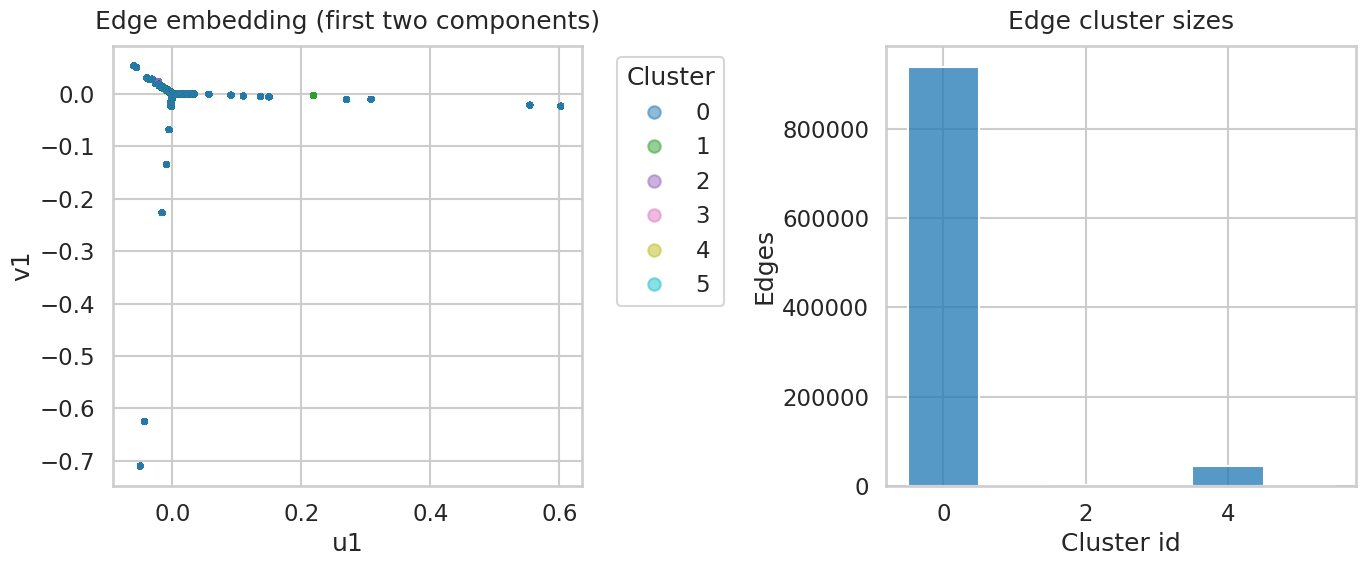

In [ ]:
edge_feats = np.hstack([U[edge_u, :N_VECTORS], V[edge_v, :N_VECTORS]])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(edge_feats[:,0], edge_feats[:,1], c=edge_labels, cmap='tab10', alpha=0.5, s=10)
axes[0].set_title('Edge embedding (first two components)')
axes[0].set_xlabel('u1')
axes[0].set_ylabel('v1')
axes[0].legend(*scatter.legend_elements(), title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.histplot(edge_labels, ax=axes[1], bins=N_CLUSTERS, discrete=True)
axes[1].set_title('Edge cluster sizes')
axes[1].set_xlabel('Cluster id')
axes[1].set_ylabel('Edges')
plt.tight_layout()
plt.show()


## Bimodularity scores and adjacency structure
- Compute a simple bimodularity index per node (share of total weight in its sending/receiving block).
- Reorder adjacency by sending and receiving communities and visualize block structure.


In [ ]:
bimod_scores = bimodularity_index(adj, send_comm, recv_comm)
score_df = pd.DataFrame({
    'node': node_list,
    'send_comm': send_comm,
    'recv_comm': recv_comm,
    'bimod_score': bimod_scores
}).sort_values('bimod_score', ascending=False)
score_df.head(10)


,node,send_comm,recv_comm,bimod_score
999,720575940661289345,0,0,0.84011
0,720575940603464672,0,0,0.84011
1,720575940604088288,0,0,0.84011
2,720575940604352172,0,0,0.84011
3,720575940604458668,0,0,0.84011
4,720575940604470240,0,0,0.84011
5,720575940604569824,0,0,0.84011
6,720575940604653484,0,0,0.84011
983,720575940648633988,0,0,0.84011
982,720575940648570244,0,0,0.84011


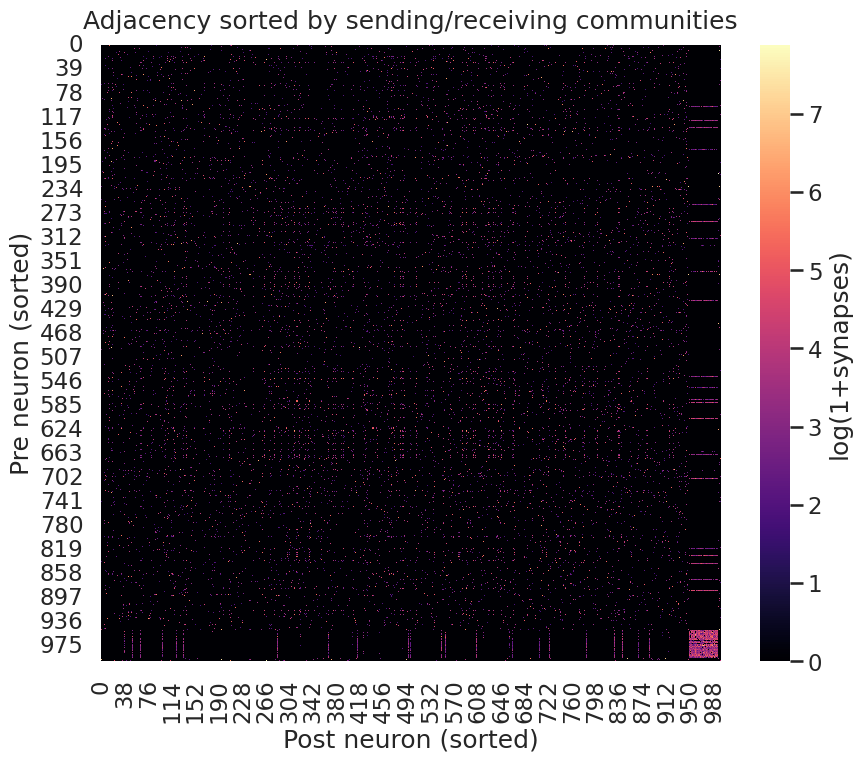

In [ ]:
order = np.argsort(send_comm * 100 + recv_comm)
A_sorted = adj[np.ix_(order, order)]

plt.figure(figsize=(10, 8))
sns.heatmap(np.log1p(A_sorted), cmap='magma', cbar_kws={'label': 'log(1+synapses)'})
plt.title('Adjacency sorted by sending/receiving communities')
plt.xlabel('Post neuron (sorted)')
plt.ylabel('Pre neuron (sorted)')
plt.show()


## Network view of top communities
Visualize the induced subgraph of the largest sending community, colored by receiving community.


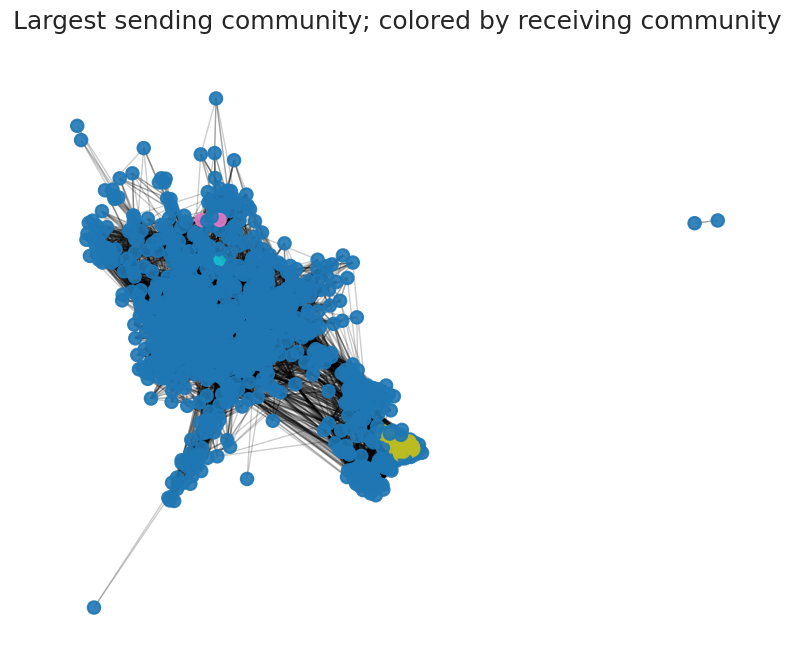

In [ ]:
largest_send = np.bincount(send_comm).argmax()
mask_send = send_comm == largest_send
sub_idx = np.where(mask_send)[0]
sub_nodes = node_list[sub_idx]
G = nx.from_numpy_array(adj[np.ix_(sub_idx, sub_idx)], create_using=nx.DiGraph)
pos = nx.spring_layout(G, weight='weight', seed=3, k=0.6)
node_colors = recv_comm[sub_idx]
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=80, node_color=node_colors, cmap='tab10', alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, arrows=False)
plt.title('Largest sending community; colored by receiving community')
plt.axis('off')
plt.show()


## Notes
- Increase `TOP_N_NODES` for higher-resolution structure (at the cost of memory).
- Adjust `N_CLUSTERS`/`N_VECTORS` to explore different bicommunity granularities.
- Swap the null model in `modularity_matrix` if you want alternative baselines.
- Export cluster assignments with `score_df.to_csv(...)` for downstream analyses or Gephi.
